Esta atividade é para vocês implementarem os modelos de DL (pode ser mais de um) escolhidos. O objetivo é que os grupos se familiarizem com a implementação destes modelos. Sugiro que vocês executem os modelos com apenas com uma base de dados de brinquedo, que é geralmente encontrada junto com a biblioteca escolhida (exemplo pytorch). Deste modo, vocês irão lidar com potenciais dúvidas sobre implementação logo cedo, antes de resolver o problema escolhido pelo grupo. Vocês poderão verificar se o modelo se comporta como esperado, validando-o para o seu problema. Além disso, vocês poderão adiantar qualquer dor de cabeça na implementação e tirar dúvidas com a maior antecedência possível. Apenas um integrante do grupo deve submeter a atividade no classroom.

vamos trabalhar com o dataset city spaces de preferência com segmentação

## importando bibliotecas

In [42]:
import torch
from torch import nn
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import DataLoader, Subset
import torchvision.models as models
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import optuna
from fvcore.nn import FlopCountAnalysis
from plotly.io import show
from pathlib import Path
import sys

In [43]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

import numpy as np
import random
np.random.seed(SEED)
random.seed(SEED)

Using device: cpu


## preparação do dataset

In [44]:
transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])

In [45]:
train_data = datasets.CelebA(root="./../datasets", split="train", target_type="landmarks", transform=transform, download=True)
test_data = datasets.CelebA(root="./../datasets", split="test", target_type="landmarks", transform=transform, download=True)
val_data = datasets.CelebA(root="./../datasets", split="valid", target_type="landmarks", transform=transform, download=True)

In [46]:
def visualize_landmarks(img, target):
    # Se a imagem vier como tensor [C, H, W]
    print("target bruto:", target)
    img_np = img.permute(1, 2, 0).numpy()

    landmarks = target.view(5, 2)
    labels = ["left eye", "right eye", "nose", "left mouth", "right mouth"]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img_np)
    ax.scatter(landmarks[:, 0], landmarks[:, 1], c="cyan", s=40)

    for (x, y), label in zip(landmarks, labels):
        ax.annotate(
            label,
            (x, y),
            textcoords="offset points",
            xytext=(5, 5),
            color="yellow",
            fontsize=8,
            bbox=dict(facecolor="black", alpha=0.5, edgecolor="none", pad=1),
        )

    ax.set_title("CelebA landmarks")
    ax.axis("off")
    plt.show()

target bruto: tensor([ 70, 111, 107, 110,  87, 130,  71, 154, 105, 152])


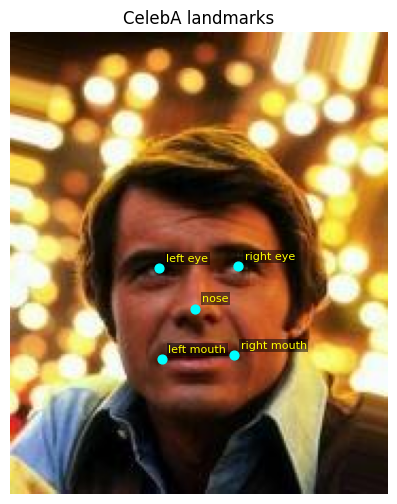

In [47]:
sample_index = torch.randint(0, len(train_data), (1,)).item()
img, target = train_data[sample_index]
visualize_landmarks(img, target)